# Supplementary Figure S41: cross-dataset benchmark summary

Recalculate the 33 matched benchmark comparisons and draw the figure from the included numerical results. This notebook does not read or re-export the published figure.


## Inputs and preceding calculation

The nine model and interpolation results come from the five completed leave-one-time-point-out benchmark runs described in the [S40 notebook](loto_benchmark.ipynb). The ARISTA and chicken-heart rows use the accepted retrained models. Linear OT was evaluated separately on the same held-out inputs and with the same five Sliced-W2 projection repeats.

The release directory contains the exact input tables, the Linear OT repeat-level metrics, the calculation and plotting script, and the run manifest.


In [1]:
from pathlib import Path
import subprocess
import sys

import pandas as pd
from IPython.display import Image, display


def find_repository(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / 'release_artifacts' / 'five_dataset_loto_summary_20260901').is_dir():
            return candidate
    raise FileNotFoundError('Run this notebook from a cytobridge-spatial source checkout.')


repository = find_repository(Path.cwd().resolve())
release = repository / 'release_artifacts' / 'five_dataset_loto_summary_20260901'
output_dir = repository / 'outputs' / 'loto_benchmark_summary'
table_dir = output_dir / 'tables'
figure_pdf = output_dir / 'five_dataset_loto_summary.pdf'
manifest = output_dir / 'run_manifest.json'
output_dir.mkdir(parents=True, exist_ok=True)
release.relative_to(repository)


PosixPath('release_artifacts/five_dataset_loto_summary_20260901')

## Recalculate and draw

The script reads the target-stage means and the repeat-level Linear OT results, recalculates the ranking and paired relative-error tables, and writes new PDF and PNG files.


In [2]:
command = [
    sys.executable,
    str(release / 'code' / 'plot_five_dataset_loto_wins_summary.py'),
    '--input', str(release / 'source_data' / 'loto_target_stage_means.csv'),
    '--linear-ot-root', str(release / 'source_data' / 'linear_ot_metrics'),
    '--table-output-dir', str(table_dir),
    '--output', str(figure_pdf),
    '--manifest', str(manifest),
]
_ = subprocess.run(command, check=True)


## Check the recalculated counts


In [3]:
display_names = {
    'CytoBridge-0.015': 'CytoBridge',
    'exact_ot_displacement': 'Linear OT displacement',
    'stvcr': 'stVCR',
    'moscot': 'MOSCOT',
    'paste': 'PASTE',
}
counts = pd.read_csv(table_dir / 'loto_win_counts.csv').rename(
    columns={'win_count': 'comparisons_with_lowest_sliced_w2'}
)
counts['method'] = counts['method'].map(display_names).fillna(counts['method'])
counts.loc[counts['comparisons_with_lowest_sliced_w2'].gt(0)].sort_values(
    'comparisons_with_lowest_sliced_w2', ascending=False
).reset_index(drop=True)


,method,comparisons_with_lowest_sliced_w2
0,CytoBridge,12
1,Linear OT displacement,11
2,PASTE,6
3,stVCR,2
4,MOSCOT,2


## Figure


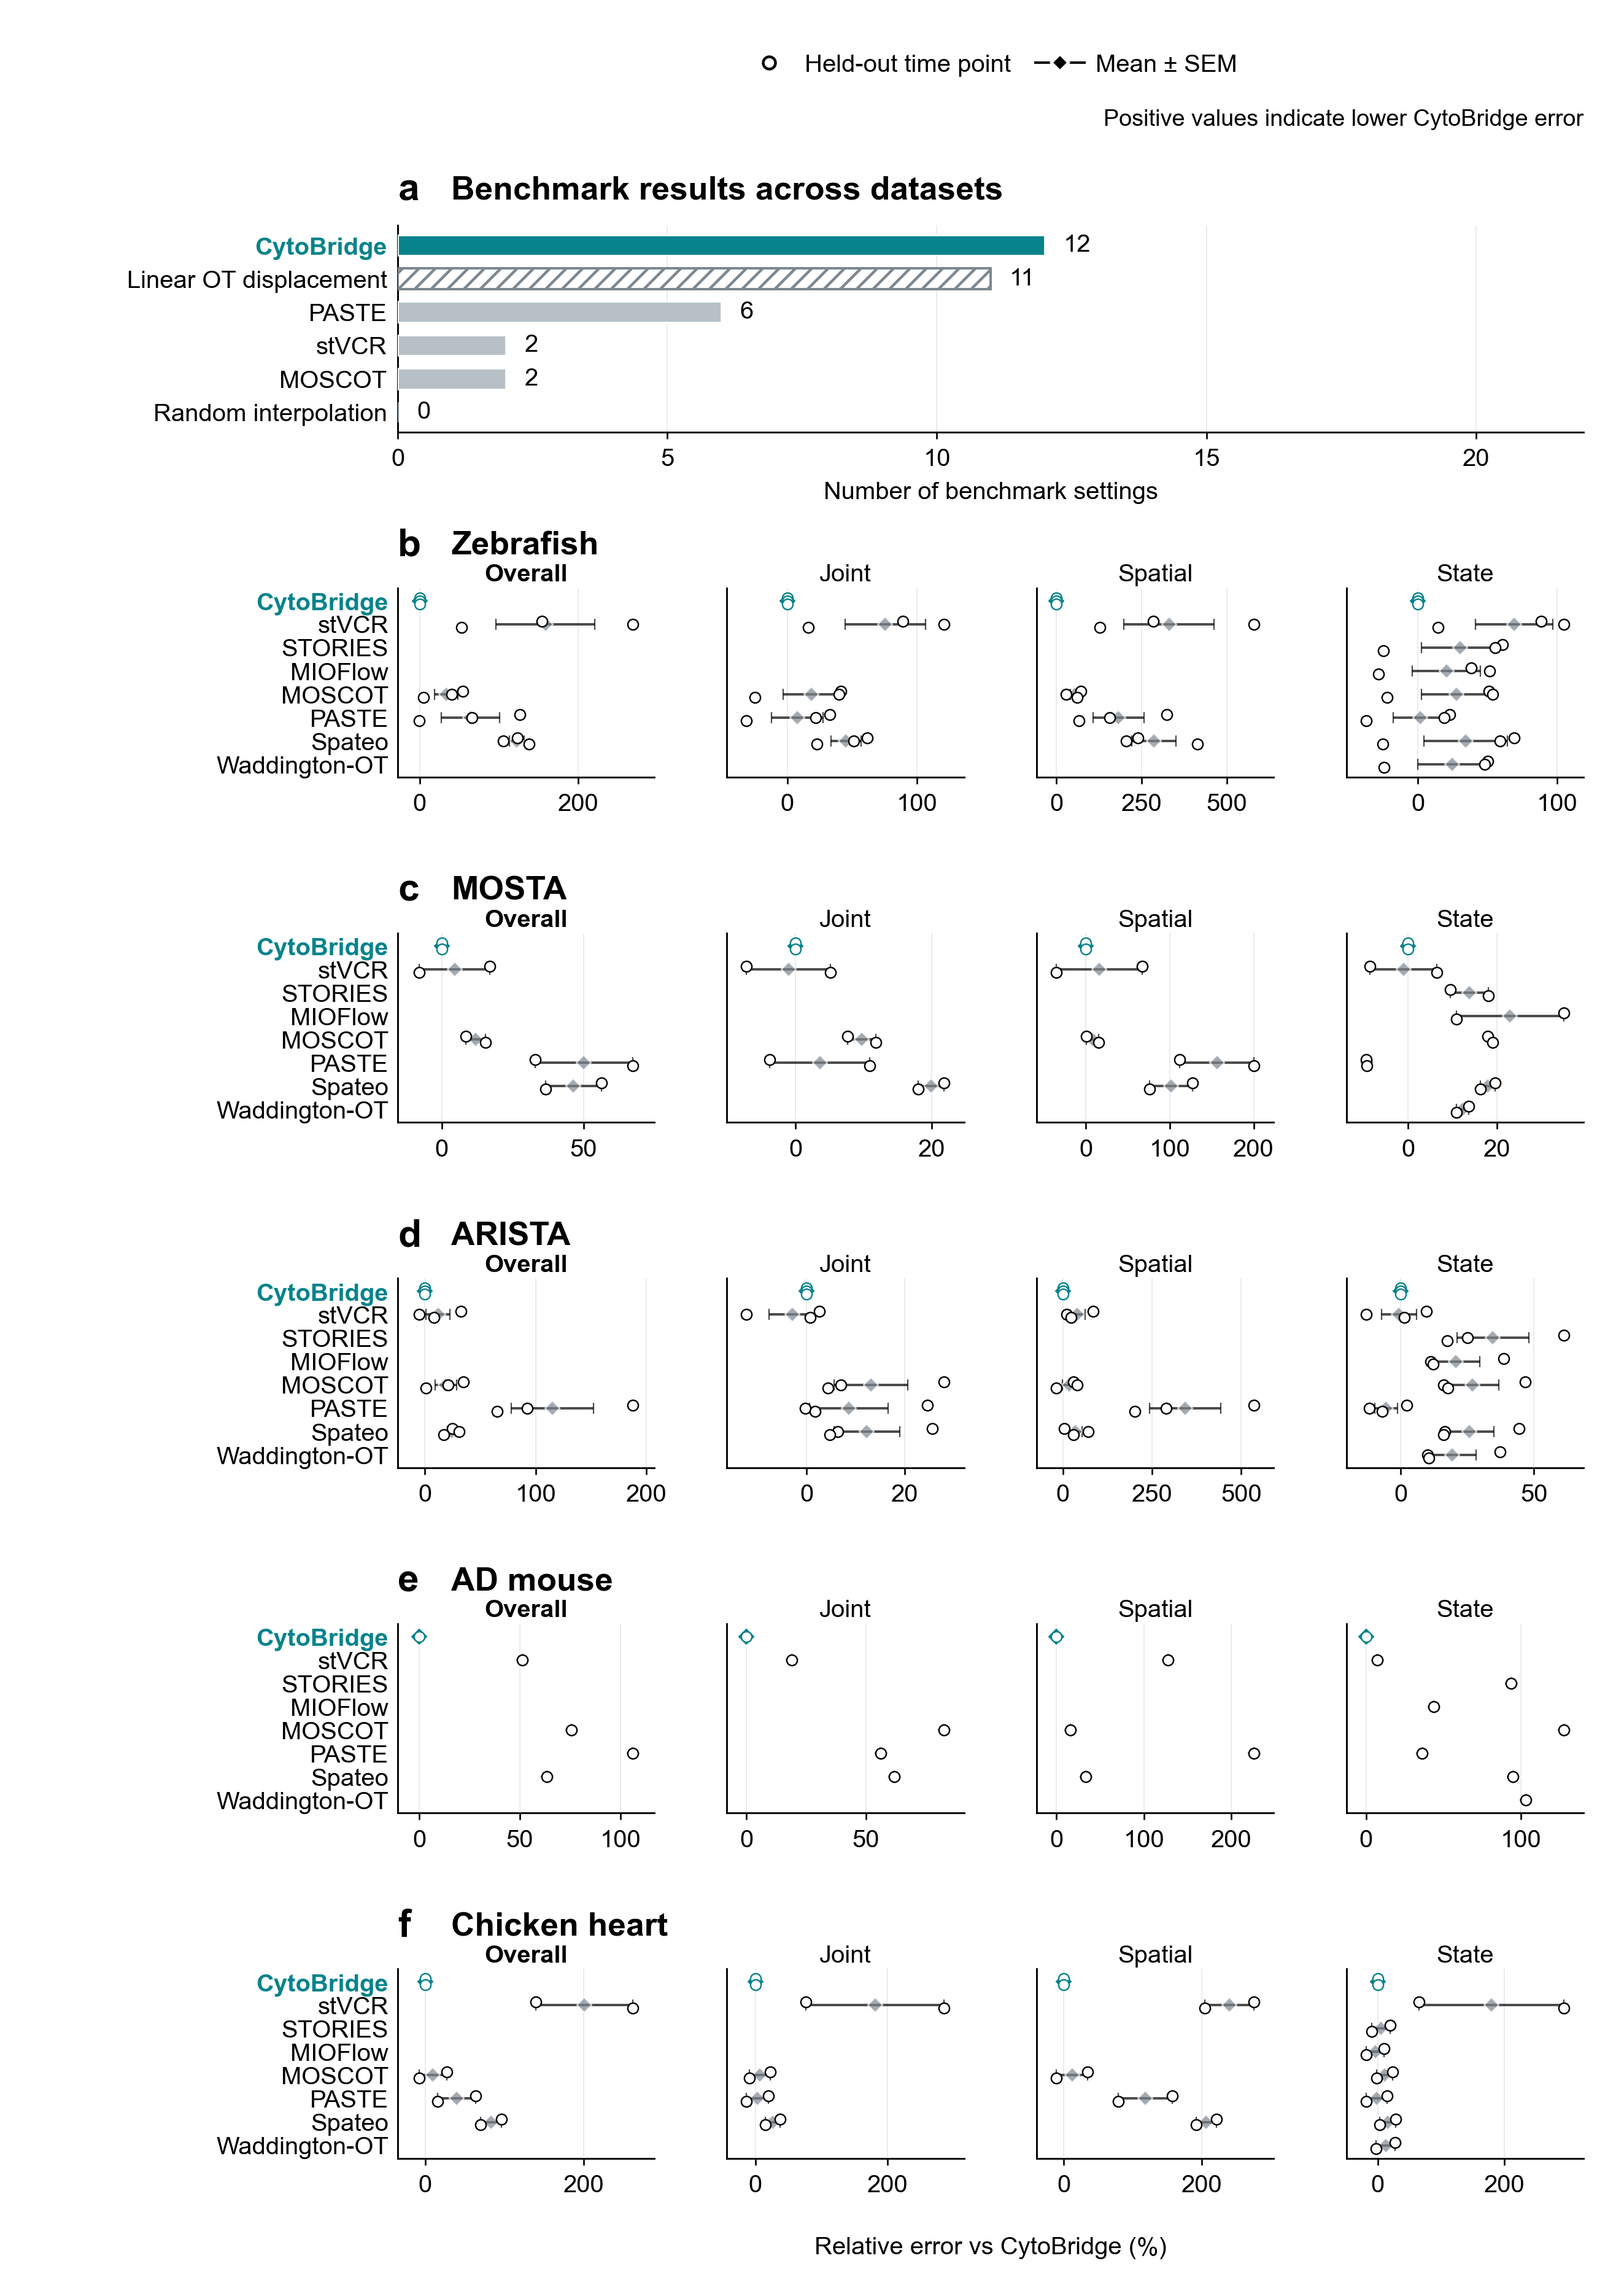

{'pdf': PosixPath('outputs/loto_benchmark_summary/five_dataset_loto_summary.pdf'),
 'png': PosixPath('outputs/loto_benchmark_summary/five_dataset_loto_summary.png'),
 'tables': ['loto_model_relative_to_cytobridge.csv',
  'loto_target_stage_means_with_linear_ot.csv',
  'loto_target_stage_ranks.csv',
  'loto_win_counts.csv'],
 'manifest': PosixPath('outputs/loto_benchmark_summary/run_manifest.json')}

In [4]:
display(Image(filename=str(figure_pdf.with_suffix('.png')), width=760))
{
    'pdf': figure_pdf.relative_to(repository),
    'png': figure_pdf.with_suffix('.png').relative_to(repository),
    'tables': sorted(path.name for path in table_dir.glob('*.csv')),
    'manifest': manifest.relative_to(repository),
}
